### **Comparando Modelos**

In [19]:
# Importando Bibliotecas
import os
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

# Importando Modelos
from src.models.unet.unet import UNet
from src.models.unet.unet_pretrained import UNet_ImageNet
from src.models.artigo_full_hrnet.full_hrnet import FullHRNet
from src.models.artigo_full_hrnet.full_hrnet_pretrained import FullHRNet_ImageNet

# Importar sua classe existente
from src.vfss_dataset import VFSSImageDataset

from src.split_data import split_data_k_fold
from src.utils import (plot_image_with_mask,
                       get_script_relative_path,
                       get_project_root_directory,
                       get_corners_from_angle,
                       clahe,
                       modify_input,
                       load_points,
                       custom_collate_fn,
                       set_seed,
                       avalia_status_GPU,
                       resolve_dataframe_path)

# Importando classes/funções - Podar imports que não são chamados aqui.
from src.training.config import TrainingConfig
from src.training.loss import (LossCalculator,
                               FocalMSELoss,
                               FocalMSEMaskedLoss)
from src.training.holdout import holdout
from src.training.cross_validation import cross_validate
from src.evalutation.inference import evaluate_model_on_test

set_seed(42)

### **Selecionando Modelos a serem comparados**

In [2]:
# Escolhendo modelos para comparar:
list_models = [r"data\model_weights\UNet_ImageNet\FocalMSEMaskedLoss_200ep",
               r"data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_32W",
               r"data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_48W"]

In [3]:
# Coletando Configurações dos modelos:

dict_config = {}
for model in list_models:
    with open(os.path.join(model,'config.pkl'), 'rb') as f:
        config_model = pickle.load(f)
        dict_config[model] = config_model

In [ ]:
# Compara Métricas dos modelos

class ModelComparator:
    def __init__(self, dict_config):
        self.dict_config = dict_config
        self.n_models = len(dict_config.keys())
        self.results = {}
        self._load_results()

    def _load_results(self):
        for model in self.dict_config:
            config = dict_config[model]
            root = config.checkpoint_dir
            pattern = re.compile(r"fold_([1-9])_best\.pth$")
            if os.path.exists(root):
                for filename in os.listdir(root):
                    match = pattern.search(filename)
                    if match:
                        checkpoint_path = os.path.join(root, filename)
                        results = evaluate_model_on_test(config, checkpoint_path, "", False)
                        self.results[checkpoint_path] = results

    def calculate_metrics(self):
        rows = []
        for model in self.results:
            row = {}

            # Distância Euclidiana
            row["mean_distance_C2"] = self.results[model]["keypoint_distances"][0].mean()
            row["median_distance_C2"] = np.median(self.results[model]["keypoint_distances"][0])
            row["mean_distance_C4"] = self.results[model]["keypoint_distances"][1].mean()
            row["median_distance_C2"] = np.median(self.results[model]["keypoint_distances"][1])

            # Loss Heatmap
            row["mean_heatmap_loss"] = self.results[model]["heatmap_losses"].mean()
            row["median_heatmap_loss"] = np.median(self.results[model]["heatmap_losses"])

            # Loss Roi
            row["mean_roi_loss"] = self.results[model]["roi_losses"].mean()
            row["median_roi_loss"] = np.median(self.results[model]["roi_losses"])

            # Loss Geral
            row["mean_total_loss"] = self.results[model]["total_losses"].mean()
            row["median_total_loss"] = np.median(self.results[model]["total_losses"])

            rows.append(row)

        dfMetrics = pd.DataFrame(rows)
        dfMetrics.index = self.results.keys()
        return dfMetrics

    def plot_boxplot_metrics(self, cols):
        for col in cols:
            if col == "keypoint_distances":
                points_c2 = []
                points_c4 = []
                for model in self.results:
                    points_c2.append(self.results[model][col][0])
                    points_c4.append(self.results[model][col][1])
                fig, ax = plt.subplots(1,2,figsize = (12, 4))
                ax[0].boxplot(points_c2, labels = self.results.keys())
                ax[0].set_title("Boxplot - Distância Euclidiana - C2")
                ax[0].tick_params(axis='x', labelrotation=90)
                ax[1].boxplot(points_c4, labels = self.results.keys())
                ax[1].set_title("Boxplot - Distância Euclidiana - C4")
                ax[1].tick_params(axis='x', labelrotation=90)
                plt.tight_layout()
                plt.show()
            else:
                model_metric = []
                for model in self.results:
                    model_metric.append(self.results[model][col])
                plt.boxplot(model_metric, labels = self.results.keys())
                plt.title(f"Boxplot - {col}")
                plt.xticks(rotation=90)
                plt.tight_layout()
                plt.show()
        return

    def percentage_correct_keypoints(self, point_true, point_pred, threshold):
        return

In [39]:
comp = ModelComparator(dict_config=dict_config)
dfMetrics = comp.calculate_metrics()

✓ Modelo carregado: data\model_weights\UNet_ImageNet\FocalMSEMaskedLoss_200ep\fold_1_best.pth
  Epoch: 2
  Val Loss: 0.0442

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:08<00:00, 20.67it/s]


HRNet 32 inicializada com 39 camadas da ImageNet.
✓ Modelo carregado: data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_32W\fold_1_best.pth
  Epoch: 17
  Val Loss: 0.0011

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:05<00:00, 30.58it/s]


HRNet 48 inicializada com 39 camadas da ImageNet.
✓ Modelo carregado: data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_48W\fold_1_best.pth
  Epoch: 27
  Val Loss: 0.0011

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:05<00:00, 31.50it/s]


C:\Users\viniciuscosta\AppData\Local\Temp\ipykernel_33708\391037848.py:67: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


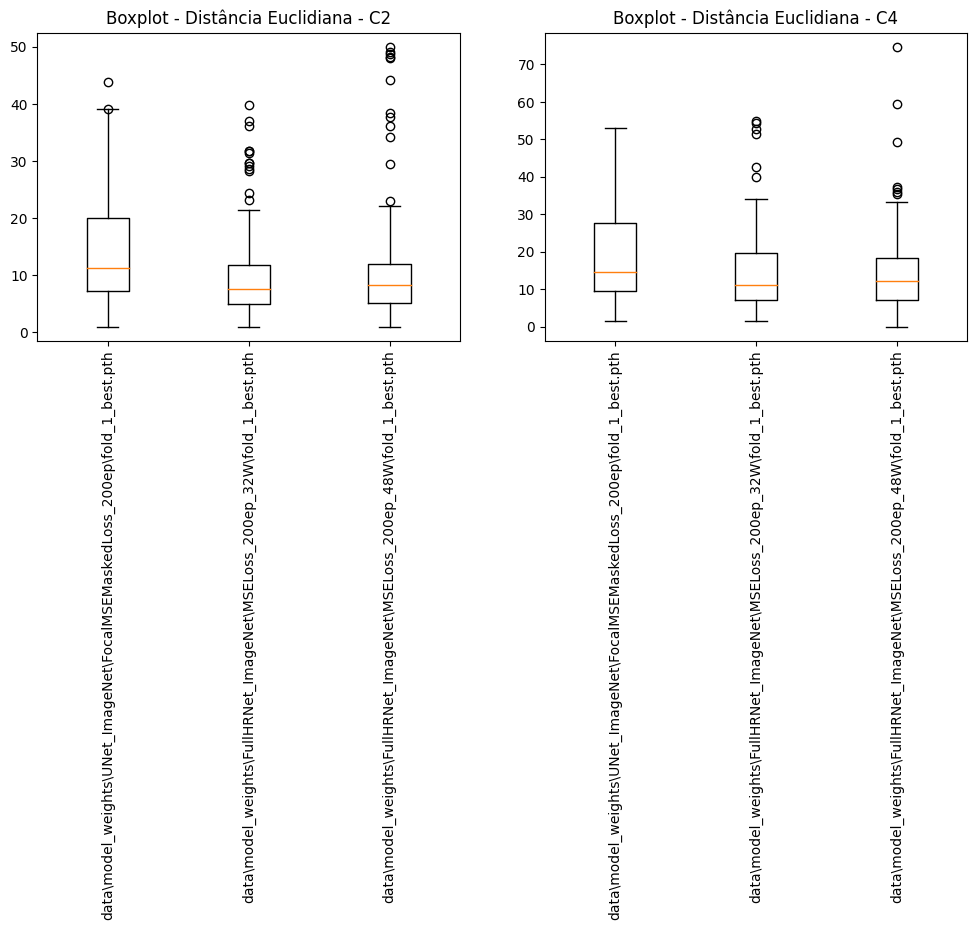

C:\Users\viniciuscosta\AppData\Local\Temp\ipykernel_33708\391037848.py:77: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


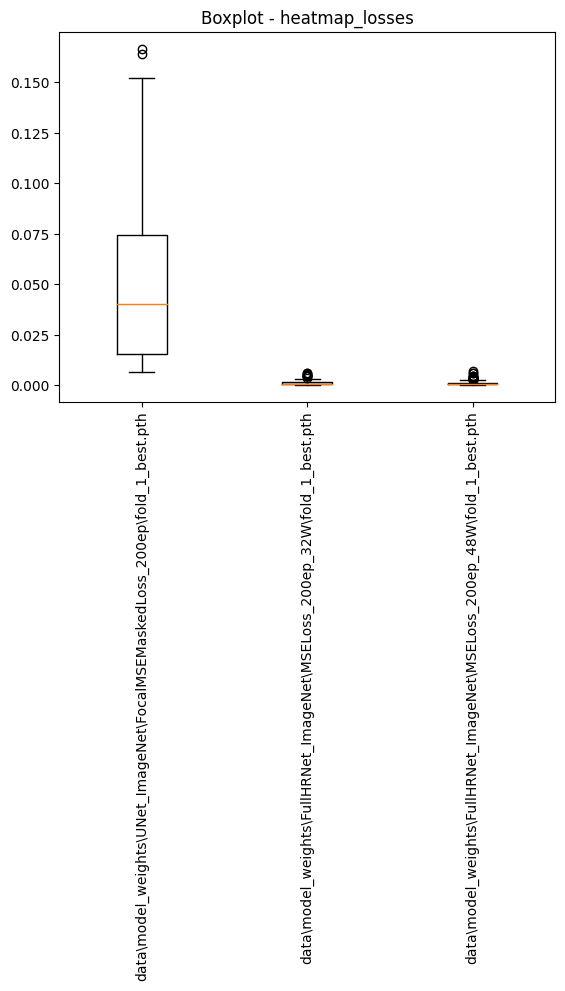

C:\Users\viniciuscosta\AppData\Local\Temp\ipykernel_33708\391037848.py:77: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


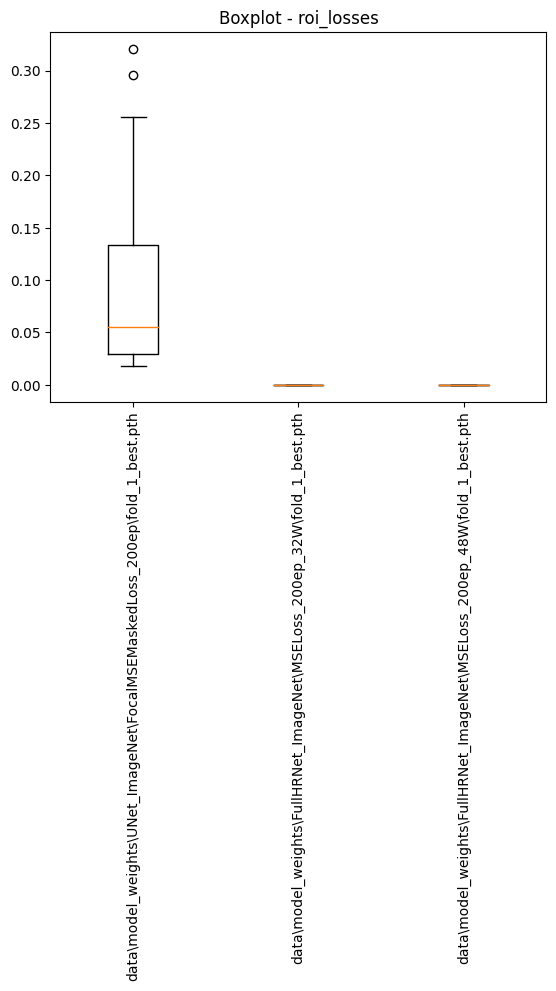

C:\Users\viniciuscosta\AppData\Local\Temp\ipykernel_33708\391037848.py:77: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


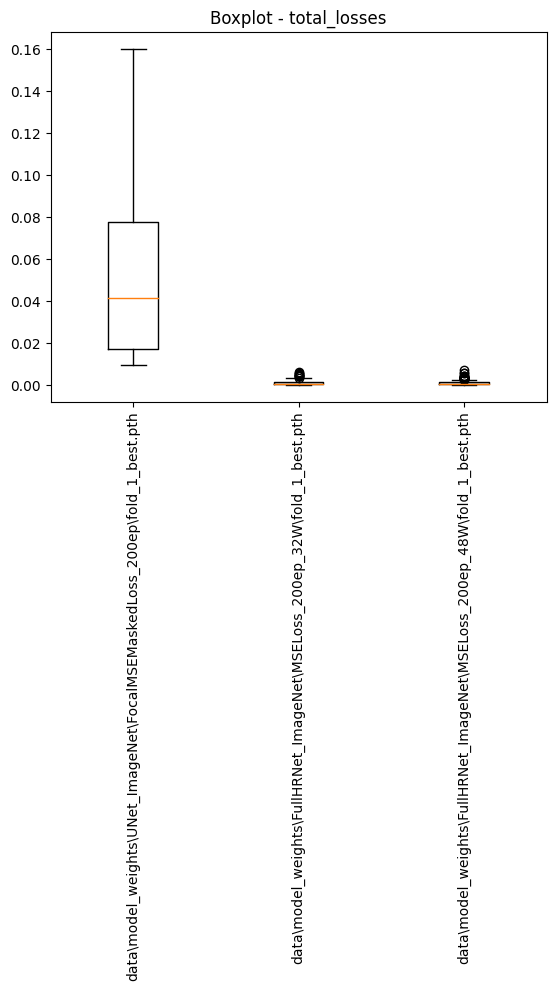

In [40]:
comp.plot_boxplot_metrics(["keypoint_distances", "heatmap_losses", "roi_losses", "total_losses"])

In [20]:
comp.results["data\\model_weights\\UNet_ImageNet\\FocalMSEMaskedLoss_200ep\\fold_1_best.pth"].keys()

dict_keys(['keypoint_distances', 'heatmap_losses', 'roi_losses', 'total_losses', 'predictions', 'ground_truths', 'images'])